In [101]:
import torch
import torch.nn as nn
import torch.optim as optim

In [102]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        Parameters
        ----------
        patience : int
            How many epochs to wait after last improvement.
        min_delta : float
            Minimum change in validation loss to qualify as improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [103]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import norm
from scipy.spatial import ConvexHull

In [104]:
# -------------------- Fixed Surrogate --------------------
class FixedNN(nn.Module):
    def __init__(self, input_dim):
        super(FixedNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
        for param in self.model.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.model(x)

In [105]:
class FixedPredictor:
    def __init__(self, input_dim):
        self.model = FixedNN(input_dim)
        self.scaler_x = StandardScaler()

    def fit(self, X):  # Only fit scaler
        self.scaler_x.fit(X)

    def predict(self, X):
        X_scaled = self.scaler_x.transform(X)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        with torch.no_grad():
            return self.model(X_tensor).numpy().ravel()

In [106]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import norm
from scipy.spatial import ConvexHull


In [107]:
class SurrogateNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(SurrogateNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)

In [108]:
class SurrogateTrainer:
    def __init__(self, input_dim, lr=1e-3, epochs=500, patience=50, min_delta=1e-4):
        """
        Parameters
        ----------
        input_dim : int
            Number of input features
        lr : float
            Learning rate
        epochs : int
            Maximum number of epochs
        patience : int
            How many epochs to wait for improvement before stopping
        min_delta : float
            Minimum improvement in validation loss to reset patience
        """
        self.model = SurrogateNN(input_dim)
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.min_delta = min_delta
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

    def fit(self, X, y, log_weights=False, val_split=0.2):
        """
        Train the surrogate NN with early stopping.

        Parameters
        ----------
        X : np.ndarray
        y : np.ndarray
        log_weights : bool
            If True, also log mean/std of weights per epoch.
        val_split : float
            Fraction of data to use for validation

        Returns
        -------
        history : dict
            {
              "train_losses": list,
              "val_losses": list,
              "weights": list of dicts (optional)
            }
        """
        # Scale data
        X_scaled = self.scaler_x.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

        # Train/val split
        n_val = int(len(X_scaled) * val_split)
        X_train, X_val = X_scaled[:-n_val], X_scaled[-n_val:]
        y_train, y_val = y_scaled[:-n_val], y_scaled[-n_val:]

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

        train_losses, val_losses, weights_log = [], [], []
        best_val_loss = np.inf
        patience_counter = 0

        for epoch in range(self.epochs):
            # ---- Training ----
            self.model.train()
            optimizer.zero_grad()
            output = self.model(X_train_tensor)
            loss = loss_fn(output, y_train_tensor)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

            # ---- Validation ----
            self.model.eval()
            with torch.no_grad():
                val_output = self.model(X_val_tensor)
                val_loss = loss_fn(val_output, y_val_tensor).item()
            val_losses.append(val_loss)

            # ---- Log weights ----
            if log_weights:
                epoch_stats = {}
                for name, param in self.model.named_parameters():
                    if param.requires_grad:
                        epoch_stats[name] = {
                            "mean": param.data.mean().item(),
                            "std": param.data.std().item()
                        }
                weights_log.append(epoch_stats)

            # ---- Early stopping ----
            if val_loss < best_val_loss - self.min_delta:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), "best_surrogate.pt")
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}, best val_loss={best_val_loss:.6f}")
                    self.model.load_state_dict(torch.load("best_surrogate.pt"))
                    break

            if (epoch + 1) % 50 == 0 or epoch == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, Train Loss: {loss.item():.6f}, Val Loss: {val_loss:.6f}")

        return {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "weights": weights_log if log_weights else None
        }

    def predict(self, X):
        X_scaled = self.scaler_x.transform(X)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            y_pred = self.model(X_tensor).numpy()
        return self.scaler_y.inverse_transform(y_pred).ravel()

    def compute_input_influence(self, X, mode='global'):
        """
        Computes input feature influence on surrogate predictions via gradient sensitivity.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Input data to evaluate gradients on.

        mode : str
            'local' → use only the first point in X
            'global' → average gradients across all points

        Returns
        -------
        influence : np.ndarray of shape (n_features,)
            Per-feature sensitivity scores (absolute gradient magnitudes).
        """
        X_scaled = self.scaler_x.transform(X)
        self.model.eval()

        if mode == 'local':
            x0 = torch.tensor(X_scaled[0], dtype=torch.float32, requires_grad=True)
            y_pred = self.model(x0)
            y_pred.backward()
            grad = x0.grad.detach().numpy()
            return np.abs(grad)

        elif mode == 'global':
            grads = []
            for x in X_scaled:
                xt = torch.tensor(x, dtype=torch.float32, requires_grad=True)
                y_pred = self.model(xt)
                y_pred.backward()
                grads.append(xt.grad.detach().numpy())
            grads = np.abs(np.stack(grads))
            return grads.mean(axis=0)

        else:
            raise ValueError("mode must be 'local' or 'global'")

In [109]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

In [110]:
class SVMFilterStrategy:
    """
    A unified strategy for training and applying SVM-based filtering
    using different labeling modes: 'median', 'gp', or 'knn'.
    """

    def __init__(self, mode='median', percentile=90, threshold=0.2, knn_k=3, kernel=None):
        """
        Parameters:
        - mode: 'median', 'gp', or 'knn'
        - percentile: for 'gp' or 'knn', top percentile to label as 'good'
        - threshold: decision boundary margin for filtering
        - knn_k: number of neighbors for KNN
        - kernel: optional GP kernel (used in 'gp' mode)
        """
        self.mode = mode
        self.percentile = percentile
        self.threshold = threshold
        self.knn_k = knn_k
        self.kernel = kernel or RBF(length_scale=0.1, length_scale_bounds='fixed')
        self.svm_clf = None
        self.scaler = None

    def fit(self, X, y, X_grid=None):
        """
        Train the SVM classifier based on the selected labeling strategy.

        Parameters:
        - X, y: known data
        - X_grid: required for 'gp' and 'knn' modes (grid to label)
        """
        if self.mode == 'median':
            labels = (y >= np.median(y)).astype(int)
            self.scaler = StandardScaler()
            X_scaled = self.scaler.fit_transform(X)
            self.svm_clf = SVC(kernel='rbf', C=1.0)
            self.svm_clf.fit(X_scaled, labels)

        elif self.mode == 'gp':
            if X_grid is None:
                raise ValueError("X_grid must be provided for 'gp' mode.")
            gp = GaussianProcessRegressor(kernel=self.kernel, alpha=1e-10)
            gp.fit(X, y)
            mean, _ = gp.predict(X_grid, return_std=True)
            cutoff = np.percentile(mean, self.percentile)
            labels = (mean >= cutoff).astype(int)
            self.scaler = StandardScaler()
            X_scaled = self.scaler.fit_transform(X_grid)
            self.svm_clf = SVC(kernel='rbf', C=1.0)
            self.svm_clf.fit(X_scaled, labels)

        elif self.mode == 'knn':
            if X_grid is None:
                raise ValueError("X_grid must be provided for 'knn' mode.")
            knn = KNeighborsRegressor(n_neighbors=self.knn_k)
            knn.fit(X, y)
            y_grid = knn.predict(X_grid)
            cutoff = np.percentile(y_grid, self.percentile)
            labels = (y_grid >= cutoff).astype(int)
            self.scaler = StandardScaler()
            X_scaled = self.scaler.fit_transform(X_grid)
            self.svm_clf = SVC(kernel='rbf', C=1.0)
            self.svm_clf.fit(X_scaled, labels)

        else:
            raise ValueError(f"Unsupported mode: {self.mode}")

    def filter(self, candidates_raw):
        """
        Apply the trained SVM to filter candidate points.

        Parameters:
        - candidates_raw: grid or candidate points to filter

        Returns:
        - filtered_candidates: subset near decision boundary
        """
        if self.svm_clf is None or self.scaler is None:
            raise RuntimeError("SVMFilterStrategy must be fit before calling filter().")

        candidates_n = self.scaler.transform(candidates_raw)
        decision_values = self.svm_clf.decision_function(candidates_n)
        mask = np.abs(decision_values) < self.threshold
        filtered = candidates_raw[mask]

        num_total = len(candidates_raw)
        num_filtered = len(filtered)
        num_excluded = num_total - num_filtered

        print(f"Filtered {num_filtered} candidates near decision boundary (|margin| < {self.threshold})")
        print(f"Excluded {num_excluded} candidates from consideration")
        print(f"Final grid shape: {filtered.shape}")

        return filtered

In [111]:
def plot_acquisition_heatmap(
    X,                   # shape (n_samples, 2): queried points
    acquisition_map,     # shape (grid_size**2,): acquisition values
    X_grid,              # shape (grid_size**2, 2): grid points
    next_query=None,     # shape (2,), optional: next query point
    title='Acquisition Heatmap',
    cmap='viridis',
    color_range=(-3, 1), # default color scale for consistency
    save_path=None       # optional: path to save plot
):
    grid_size = int(np.sqrt(len(acquisition_map)))
    acquisition_2d = acquisition_map.reshape(grid_size, grid_size)

    # Compute extent from grid
    x_min, x_max = X_grid[:, 0].min(), X_grid[:, 0].max()
    y_min, y_max = X_grid[:, 1].min(), X_grid[:, 1].max()
    extent = [x_min, x_max, y_min, y_max]

    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        acquisition_2d,
        origin='lower',
        extent=extent,
        cmap=cmap,
        aspect='auto',
        vmin=color_range[0],
        vmax=color_range[1]
    )
    plt.colorbar(im, label='Acquisition Value')

    # Queried points
    plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Queried Points')

    # Next query
    if next_query is not None:
        plt.plot(next_query[0], next_query[1], 'r*', markersize=14, label='Next Query')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

In [112]:
# Example DataFrame
def add_points_to_df(df, results):
    """
    Appends rows to df using:
    - x values from each result
    - an empty string for 'yield'
    - the method name as 'source'
    """
    for result in results:
        point = list(result['x'])
        row = point + [np.nan] + ['week-x']
        df.loc[len(df)] = row

In [113]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_output_points(df, scale_factor=1.0, yield_scale_factor=1.0, nan_marker='o'):
    """
    Plots the second-to-last column as 'Yield' and all other columns (except the last)
    as scaled variables, each with a unique color and no connecting lines.

    Parameters:
    - df: pandas DataFrame
    - scale_factor: numeric value to multiply non-yield variables (default is 1000)
    - nan_marker: marker style for points where 'yield' is missing (default is 'o')
    """
    columns = df.columns
    yield_col = columns[-2]
    other_cols = [col for col in df.columns if col != yield_col and col != columns[-1]]

    # Clean and convert yield column
    df[yield_col] = df[yield_col].replace('', np.nan)

    # Generate distinct colors
    cmap = cm.get_cmap('tab10', len(other_cols))

    # Plot yield values (non-NaN)
    if df[yield_col].notna().any():
        plt.plot(df[yield_col].astype(float) * yield_scale_factor, marker='x', linestyle='none', label=yield_col, color='black')

    # Plot missing yield points using nan_marker
    missing_yield_indices = df[yield_col].isna()
    if missing_yield_indices.any():
        plt.plot(df.index[missing_yield_indices], [0] * missing_yield_indices.sum(),
                 marker=nan_marker, linestyle='none', label='missing yield', color='gray')

    # Plot other variables scaled by scale_factor
    for i, col in enumerate(other_cols):
        plt.plot(df[col].astype(float) * scale_factor, marker='.', linestyle='none', label=col, color=cmap(i))

    plt.xlabel('Index')
    plt.ylabel('Output y')
    plt.title('Output Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

In [114]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

def plot_surrogate_generic(X_grid, y_pred, 
                           X_filtered=None, 
                           bounds=None,
                           candidates=None,
                           candidate_labels=None,
                           title="NN Surrogate"):
    """
    Plot surrogate predictions with optional filtered points and candidate queries.

    Parameters
    ----------
    X_grid : array of shape (N, d)
        Grid points (can be full or filtered)
    y_pred : array of shape (N,)
        Surrogate predictions
    X_filtered : array of shape (M, d), optional
        Points actually evaluated (highlighted separately)
    bounds : list of (min, max) for each dimension, optional
        Defines the bounding box of the unfiltered grid
    candidates : array of shape (K, d), optional
        Candidate query points selected via Bayesian optimisation
    candidate_labels : list of str, optional
        Labels for candidate points (e.g., iteration index or acquisition score)
    title : str
        Plot title
    """
    d = X_grid.shape[1]

    if d == 1:
        plt.figure(figsize=(6,4))
        plt.plot(X_grid[:,0], y_pred, label="NN surrogate")

        if X_filtered is not None:
            plt.scatter(X_filtered[:,0], 
                        np.interp(X_filtered[:,0], X_grid[:,0], y_pred),
                        color="red", label="Filtered points")

        if candidates is not None:
            plt.scatter(candidates[:,0],
                        np.interp(candidates[:,0], X_grid[:,0], y_pred),
                        color="blue", marker="*", s=120, label="Candidate queries")
            if candidate_labels is not None:
                for i, pt in enumerate(candidates):
                    plt.text(pt[0], 
                             np.interp(pt[0], X_grid[:,0], y_pred),
                             candidate_labels[i],
                             color="blue", fontsize=9, ha="left")

        if bounds is not None:
            x_min, x_max = bounds[0]
            plt.axvline(x_min, color="black", linestyle="--", label="Bounds")
            plt.axvline(x_max, color="black", linestyle="--")

        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title(title)
        plt.legend()
        plt.show()

    elif d == 2:
        plt.figure(figsize=(6,5))
        scatter = plt.scatter(X_grid[:,0], X_grid[:,1], 
                              c=y_pred, cmap="viridis", s=20)
        plt.colorbar(scatter, label="Model prediction")

        if X_filtered is not None:
            plt.scatter(X_filtered[:,0], X_filtered[:,1], 
                        c="red", edgecolor="black", s=40, label="Filtered points")

        if candidates is not None:
            plt.scatter(candidates[:,0], candidates[:,1],
                        c="blue", marker="*", s=120, label="Candidate queries")
            if candidate_labels is not None:
                for i, pt in enumerate(candidates):
                    plt.text(pt[0], pt[1], candidate_labels[i],
                             color="blue", fontsize=9, ha="left")

        if bounds is not None:
            x_min, x_max = bounds[0]
            y_min, y_max = bounds[1]
            rect_x = [x_min, x_max, x_max, x_min, x_min]
            rect_y = [y_min, y_min, y_max, y_max, y_min]
            plt.plot(rect_x, rect_y, color="black", linewidth=2, label="Bounds")

        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(title)
        plt.legend()
        plt.show()

    else:
        i, j = 0, 1
        plt.figure(figsize=(6,5))
        scatter = plt.scatter(X_grid[:,i], X_grid[:,j], c=y_pred, cmap="viridis", s=20)
        plt.colorbar(scatter, label="Model prediction")

        if X_filtered is not None:
            plt.scatter(X_filtered[:,i], X_filtered[:,j], 
                        c="red", edgecolor="black", s=40, label="Filtered points")

        if candidates is not None:
            plt.scatter(candidates[:,i], candidates[:,j],
                        c="blue", marker="*", s=120, label="Candidate queries")
            if candidate_labels is not None:
                for idx, pt in enumerate(candidates):
                    plt.text(pt[i], pt[j], candidate_labels[idx],
                             color="blue", fontsize=9, ha="left")

        if bounds is not None:
            x_min, x_max = bounds[i]
            y_min, y_max = bounds[j]
            rect_x = [x_min, x_max, x_max, x_min, x_min]
            rect_y = [y_min, y_min, y_max, y_max, y_min]
            plt.plot(rect_x, rect_y, color="black", linewidth=2, label="Bounds")

        plt.xlabel(f"x{i}")
        plt.ylabel(f"x{j}")
        plt.title(f"{title} (dims {i},{j})")
        plt.legend()
        plt.show()

def plot_loss_curve(history, title="Training Loss Curve"):
    plt.figure(figsize=(6,4))
    plt.plot(history["train_losses"], label="Training loss")   # <-- dict access
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_weight_evolution(history, layer_name="model.0.weight", stat="mean", title="Weight Evolution"):
    """
    Plot weight evolution after training using the history dict.
    
    Parameters
    ----------
    history : dict returned by SurrogateTrainer.fit
    layer_name : str, name of the layer to track (e.g. 'model.0.weight')
    stat : str, which statistic to plot ('mean' or 'std')
    title : str, plot title
    """
    if history["weights"] is None:
        raise ValueError("No weight log found. Run fit with log_weights=True.")

    values = [epoch_stats[layer_name][stat] for epoch_stats in history["weights"]]

    plt.figure(figsize=(6,4))
    plt.plot(values)
    plt.xlabel("Epoch")
    plt.ylabel(f"{stat} value")
    plt.title(title)
    plt.show()

In [115]:
def extract_candidates_and_labels(query_results, include_score=False):
    """
    Convert query_results into candidate points and labels for plotting.
    
    Parameters
    ----------
    query_results : list of dict
        Logged candidates from log_query_candidate
    include_score : bool
        Whether to append acquisition score to labels
    
    Returns
    -------
    candidates : np.ndarray of shape (K, d)
    labels : list of str
    """
    candidates = np.array([entry['x'] for entry in query_results])
    labels = []
    for entry in query_results:
        if entry['method'] in ['PI', 'EI']:
            label = f"{entry['method']} (xi={entry['xi']})"
        else:  # UCB
            label = f"{entry['method']} (kappa={entry['kappa']})"
        if include_score:
            label += f", score={entry['score']:.3f}"
        labels.append(label)
    return candidates, labels

In [116]:
from sklearn.svm import SVC
def train_svm_classifier_on_median(X, y):
    """
    Train an SVM classifier on input-output data using median split.
    
    Returns:
    - svm_clf: trained SVM classifier
    - x_scaler: fitted StandardScaler
    """
    median_y = np.median(y)
    labels = (y >= median_y).astype(int)

    x_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X)

    svm_clf = SVC(kernel='rbf', C=1.0)
    svm_clf.fit(X_scaled, labels)

    return svm_clf, x_scaler

In [117]:
import numpy as np

def create_nd_grid(bounds, grid_size=50, downsample=False, stride=2):
    """
    Create an N-dimensional grid over the given bounds, with optional downsampling.

    Parameters
    ----------
    bounds : list of tuple
        List of (low, high) tuples specifying the range for each dimension.
        Example: [(0, 1), (0, 1)] for a 2D unit square.
    
    grid_size : int, default=50
        Number of points per axis before downsampling.
    
    downsample : bool, default=False
        Whether to downsample the grid along each axis.
    
    stride : int, default=2
        Downsampling stride. Only used if `downsample=True`.
        Example: stride=2 → take every 2nd point along each axis.

    Returns
    -------
    grid : ndarray of shape (M, D)
        Flattened grid of points, where:
        - D = number of dimensions (len(bounds))
        - M = number of points (depends on downsampling)

    Notes
    -----
    - Full grid size = grid_size^D
    - Downsampled grid size ≈ (grid_size / stride)^D
    - Uses `np.meshgrid` with 'ij' indexing for consistency.
    """
    dim = len(bounds)
    print(f"Using {dim} dimensions.")

    # Build axes
    axes = []
    for low, high in bounds:
        axis = np.linspace(low, high, grid_size)
        if downsample:
            axis = axis[::stride]
        axes.append(axis)

    # Report sizes
    total_pre = grid_size ** dim
    total_post = len(axes[0]) ** dim
    print(f"Points before downsampling: {total_pre}")
    print(f"Points after downsampling: {total_post}")

    # Meshgrid and flatten
    mesh = np.meshgrid(*axes, indexing='ij')
    grid = np.stack([m.ravel() for m in mesh], axis=-1)

    print(f"Final grid shape: {grid.shape}")
    return grid

In [118]:
def train_svm_on_gp_mean(X, y, X_grid, percentile=90, kernel=None):
    """
    Train an SVM using GP mean predictions on the grid to label points.
    
    Parameters:
    - X, y: Known data
    - X_grid: Grid points to label and train on
    - percentile: Percentile threshold for 'good' labeling
    - kernel: Optional GP kernel
    
    Returns:
    - svm_clf: Trained SVM
    - x_scaler: Scaler fitted on grid
    """
    if kernel is None:
        kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')

    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, y)

    mean, _ = gp.predict(X_grid, return_std=True)
    threshold = np.percentile(mean, percentile)
    labels = (mean >= threshold).astype(int)

    x_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X_grid)

    svm_clf = SVC(kernel='rbf', C=1.0)
    svm_clf.fit(X_scaled, labels)

    return svm_clf, x_scaler

In [119]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

def train_svm_on_knn_labels(X, y, X_grid, percentile=90, knn_k=3):
    """
    Train an SVM using KNN-predicted labels on the grid.
    
    Parameters:
    - X, y: Known data
    - X_grid: Grid points to label and train on
    - percentile: Percentile threshold for 'good' labeling
    - knn_k: Number of neighbors for KNN
    
    Returns:
    - svm_clf: Trained SVM classifier
    - x_scaler: Scaler fitted on grid
    """
    knn = KNeighborsRegressor(n_neighbors=knn_k)
    knn.fit(X, y)
    y_grid = knn.predict(X_grid)

    threshold = np.percentile(y_grid, percentile)
    labels = (y_grid >= threshold).astype(int)

    x_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X_grid)

    svm_clf = SVC(kernel='rbf', C=1.0)
    svm_clf.fit(X_scaled, labels)

    return svm_clf, x_scaler

In [120]:
def filter_candidates_with_svm(candidates_raw, svm_clf, x_scaler):
    """
    Filters candidate points using a trained SVM classifier.

    This function applies a fitted StandardScaler to the candidate points,
    then uses the trained SVM to predict binary labels. It retains only those
    candidates classified as 'good' (label = 1), based on the SVM's decision.

    Parameters:
    ----------
    candidates_raw : np.ndarray of shape (M, N)
        The raw grid or candidate points to be filtered. Each row is a point in N-dimensional space.

    svm_clf : sklearn.svm.SVC
        A trained SVM classifier that was fit on scaled data with binary labels.

    x_scaler : sklearn.preprocessing.StandardScaler
        A fitted scaler used to transform candidate points before SVM prediction.
        Must match the scaler used during SVM training.

    Returns:
    -------
    good_candidates_raw : np.ndarray of shape (K, N)
        A subset of candidates_raw that were predicted as 'good' by the SVM (label = 1).
        If no points are classified as good, the full grid is returned with a warning.
    """
    if svm_clf is None:
        print("No SVM classifier provided. Returning all candidates.")
        return candidates_raw

    candidates_n = x_scaler.transform(candidates_raw)
    predicted_labels = svm_clf.predict(candidates_n)
    good_idx = np.where(predicted_labels == 1)[0]

    if len(good_idx) > 0:
        good_candidates_raw = candidates_raw[good_idx]
        print(f"Reduced candidates to {len(good_candidates_raw)} promising ones using SVM.")
    else:
        good_candidates_raw = candidates_raw
        print("No promising candidates found. Returning full grid.")

    print("Reduced candidates =", good_candidates_raw.shape)
    return good_candidates_raw

In [121]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import numpy as np
from scipy.spatial import ConvexHull


def select_next_query_multi(X, y, method='PI', xi=0.1, kappa=2.0, grid_size=100, dimension=None,
                            apply_scaling=False, title="Acquisition Function", kernel=None, filter_mode='gp'):
    """
    Selects the next query point using a specified acquisition strategy.

    Parameters:
    - X: np.ndarray of shape (n_samples, n_features), input features
    - y: np.ndarray of shape (n_samples,), output values
    - method: str, one of 'PI', 'EI', 'UCB'
    - xi: float, exploration parameter for PI/EI
    - kappa: float, exploration parameter for UCB
    - grid_size: int, resolution of the search grid
    - apply_scaling: bool, whether to standardize y
    - title: str, plot title
    - kernel: sklearn.gaussian_process.kernels object, optional custom kernel

    Returns:
    - next_query: np.ndarray of shape (n_features,), the selected input point
    - acquisition_map: np.ndarray of shape (grid_size**n,), acquisition values
    - X_grid: np.ndarray of shape (grid_size**n, n_features), grid points evaluated
    - mean: np.ndarray of shape (grid_size**n,), GP mean predictions
    - std: np.ndarray of shape (grid_size**n,), GP std predictions
    """
    if apply_scaling:
        scaler = StandardScaler()
        y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

    n_features = X.shape[1]
    print("Number of features: ", n_features)
    # original bounds
    #bounds = [(0, 1)] * n_features
    #week-3 - changing bounds
    margin = 0.1
    bounds = [(np.min(X[:, i]) - margin, np.max(X[:, i]) + margin) for i in range(X.shape[1])]
    #end week-3 - changing bounds
    X_grid = create_nd_grid(bounds, grid_size, dimension)
    
    # Train strategy using GP mean labeling
    strategy = SVMFilterStrategy(filter_mode, percentile=90, threshold=0.2)
    strategy.fit(X, y, X_grid=X_grid)
    # Filter grid
    X_grid = strategy.filter(X_grid)

    # Use provided kernel or default to fixed RBF
    if kernel is None:
        kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')

    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, y)
    
    mean, std = gp.predict(X_grid, return_std=True)
    print("Mean ", len(mean))
    print("Std  ", len(std))

    if method == 'PI':
        y_max = np.max(y)
        z = (mean - y_max - xi) / (std + 1e-12)
        acquisition_map = norm.cdf(z)

    elif method == 'EI':
        y_max = np.max(y)
        z = (mean - y_max - xi) / (std + 1e-12)
        acquisition_map = (mean - y_max - xi) * norm.cdf(z) + std * norm.pdf(z)

    elif method == 'UCB':
        acquisition_map = mean + kappa * std

    else:
        raise ValueError("Unsupported method. Choose from 'PI', 'EI', or 'UCB'.")

    best_index = np.argmax(acquisition_map)
    next_query = X_grid[best_index]

    return next_query, acquisition_map, X_grid

In [122]:
import numpy as np

def select_next_query_multi_fixedNN(X, y, method='PI', xi=0.1, kappa=2.0, grid_size=100,
                                    apply_scaling=False, filter_mode='gp', dimension=None):
    """
    Selects the next query point using a fixed (untrained) neural network surrogate model
    and an acquisition function over a filtered input grid.

    Parameters:
    ----------
    X : np.ndarray of shape (n_samples, n_features)
        Observed input features.

    y : np.ndarray of shape (n_samples,)
        Observed target values.

    method : str
        Acquisition function to use: 'PI', 'EI', or 'UCB'.

    xi : float
        Exploration parameter for PI/EI.

    kappa : float
        Exploration parameter for UCB.

    grid_size : int
        Number of points per axis in the search grid.

    apply_scaling : bool
        Whether to standardize `y` before filtering.

    filter_mode : str
        SVM filtering mode: 'gp', 'nn', etc.

    dimension : int or None
        If set, downsample grid to use only the first `dimension` features.
        Useful for reducing grid size in high-dimensional spaces.

    Returns:
    -------
    next_query : np.ndarray
        Selected input point with highest acquisition score.

    acquisition_map : np.ndarray
        Acquisition values over filtered grid.

    X_grid_filtered : np.ndarray
        Filtered grid of candidate points.
    """
    n_features = X.shape[1]
    print(f"Input space dimension: {n_features}")

    # Step 1: Compute bounds and downsample dimensions if requested
    bounds = compute_bounds(X)
    if dimension is not None:
        if dimension > n_features:
            raise ValueError(f"Requested dimension {dimension} exceeds feature count {n_features}")
        bounds = bounds[:dimension]
        print(f"Downsampling grid to first {dimension} dimensions.")

    # Step 2: Create grid
    X_grid_full = create_nd_grid(bounds, grid_size)
    print(f"Points before downsampling: {X_grid_full.shape[0]}")

    # Step 3: Initialize and fit fixed predictor
    predictor = FixedPredictor(input_dim=n_features)
    predictor.fit(X)

    # Step 4: Predict surrogate outputs on full grid for filtering
    y_grid = predictor.predict(X_grid_full)

    # Step 5: Filter grid using SVM strategy
    X_grid_filtered = filter_grid(X, y, X_grid_full, filter_mode)
    print(f"Final grid shape: {X_grid_filtered.shape}")

    if X_grid_filtered.shape[0] == 0:
        print("⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.")
        return None, None, None

    # Step 6: Predict again on filtered grid
    mean = predictor.predict(X_grid_filtered)
    std = np.ones_like(mean) * 0.1  # fixed uncertainty

    # Step 7: Compute acquisition and select best point
    acquisition_map = compute_acquisition(method, mean, std, y, xi, kappa)
    best_index = np.argmax(acquisition_map)
    next_query = X_grid_filtered[best_index]

    return next_query, acquisition_map, X_grid_filtered

In [123]:
from sklearn.metrics import pairwise_distances
import numpy as np

def select_next_query_multi_NNtrain(X, y, method='PI', xi=0.1, kappa=2.0, grid_size=100,
                                    apply_scaling=False, filter_mode='gp', dimension=None):
    """
    Selects the next query point using a trained neural network surrogate model
    and an acquisition function over a filtered input grid.

    Parameters
    ----------
    X : np.ndarray of shape (n_samples, n_features)
        Observed input features.

    y : np.ndarray of shape (n_samples,)
        Observed target values.

    method : str
        Acquisition function to use: 'PI', 'EI', or 'UCB'.

    xi : float
        Exploration parameter for PI/EI.

    kappa : float
        Exploration parameter for UCB.

    grid_size : int
        Number of points per axis in the search grid.

    apply_scaling : bool
        Whether to standardize `y` before filtering.

    filter_mode : str
        SVM filtering mode: 'gp', 'nn', etc.

    dimension : int or None
        If set, downsample grid to use only the first `dimension` features.

    Returns
    -------
    next_query : np.ndarray
        Selected input point with highest acquisition score.

    acquisition_map : np.ndarray
        Acquisition values over filtered grid.

    X_grid_filtered : np.ndarray
        Filtered grid of candidate points.
    """
    n_features = X.shape[1]
    print(f"Input space dimension: {n_features}")

    # Step 1: Preprocess y
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: Compute bounds and downsample dimensions if requested
    bounds = compute_bounds(X, margin=0.1)
    if dimension is not None:
        if dimension > n_features:
            raise ValueError(f"Requested dimension {dimension} exceeds feature count {n_features}")
        bounds = bounds[:dimension]
        print(f"Downsampling grid to first {dimension} dimensions.")

    # Step 3: Create grid
    X_grid_full = create_nd_grid(bounds, grid_size)
    print(f"Points before filtering: {X_grid_full.shape[0]}")

    # Step 4: Filter grid using SVM strategy
    X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)
    print(f"Final grid shape: {X_grid_filtered.shape}")

    if X_grid_filtered.shape[0] == 0:
        print("⚠️ Warning: SVM filter removed all grid points. Skipping this configuration.")
        return None, None, None

    # Step 5: Train surrogate (NN) on observed data
    trainer = SurrogateTrainer(input_dim=n_features)
    trainer.fit(X, y_proc)

    # Step 6: Predict surrogate outputs on filtered grid
    mean = trainer.predict(X_grid_filtered)

    # Step 7: Estimate uncertainty (distance-based heuristic)
    dist = pairwise_distances(X_grid_filtered, X)
    std = np.min(dist, axis=1)

    # Step 8: Compute acquisition via shared utility
    acquisition_map = compute_acquisition(method, mean, std, y_proc, xi=xi, kappa=kappa)

    # Step 9: Select best point
    best_index = np.argmax(acquisition_map)
    next_query = X_grid_filtered[best_index]

    return next_query, acquisition_map, X_grid_filtered

In [124]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import numpy as np

# --- Shared Utilities ---

def preprocess_y(y, apply_scaling=False):
    if apply_scaling:
        print("Applying standard scaling to y.")
        scaler = StandardScaler()
        y = scaler.fit_transform(y.reshape(-1, 1)).ravel()
    else:
        print("Skipping scaling.")
    return y

def compute_bounds(X, margin=0.1):
    print(f"Computing bounds with margin {margin}.")
    bounds = [(np.min(X[:, i]) - margin, np.max(X[:, i]) + margin) for i in range(X.shape[1])]
    print("Bounds per feature:", bounds)
    return bounds

def filter_grid(X, y, X_grid, filter_mode='gp'):
    print(f"Filtering grid using mode: {filter_mode}")
    print("Grid shape before filtering:", X_grid.shape)
    strategy = SVMFilterStrategy(filter_mode, percentile=90, threshold=0.2)
    strategy.fit(X, y, X_grid=X_grid)
    X_filtered = strategy.filter(X_grid)
    print("Filtered grid shape:", X_filtered.shape)
    return X_filtered

def train_gp(X, y, kernel=None):
    if kernel is None:
        kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
        print("Using default RBF kernel.")
    else:
        print("Using custom kernel.")
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, y)
    print("GP model trained.")
    return gp

def compute_acquisition(method, mean, std, y, xi=0.1, kappa=2.0):
    y_max = np.max(y)
    print(f"Computing acquisition for method: {method}")
    if method == 'PI':
        z = (mean - y_max - xi) / (std + 1e-12)
        return norm.cdf(z)
    elif method == 'EI':
        z = (mean - y_max - xi) / (std + 1e-12)
        return (mean - y_max - xi) * norm.cdf(z) + std * norm.pdf(z)
    elif method == 'UCB':
        return mean + kappa * std
    else:
        raise ValueError("Unsupported method. Choose from 'PI', 'EI', or 'UCB'.")

def select_next_query_from_gp(gp=None, X_grid=None, y=None, method='PI', xi=0.1, kappa=2.0, mean=None, std=None):
    if mean is None or std is None:
        if gp is None or X_grid is None:
            raise ValueError("Must provide either (gp, X_grid) or (mean, std)")
        mean, std = gp.predict(X_grid, return_std=True)
        print("Computed GP predictions inside function.")
    else:
        print("Using cached GP predictions.")

    acquisition_map = compute_acquisition(method, mean, std, y, xi, kappa)
    best_index = np.argmax(acquisition_map)
    next_query = X_grid[best_index]
    return next_query, acquisition_map, mean, std

In [125]:
def plot_acquisition_heatmap(
    X,                   # shape (n_samples, 2): queried points
    acquisition_map,     # shape (grid_size**2,): acquisition values
    X_grid,              # shape (grid_size**2, 2): grid points
    next_query=None,     # shape (2,), optional: next query point
    title='Acquisition Heatmap',
    cmap='viridis',
    color_range=(-3, 1), # default color scale for consistency
    save_path=None       # optional: path to save plot
):
    grid_size = int(np.sqrt(len(acquisition_map)))
    acquisition_2d = acquisition_map.reshape(grid_size, grid_size)

    # Compute extent from grid
    x_min, x_max = X_grid[:, 0].min(), X_grid[:, 0].max()
    y_min, y_max = X_grid[:, 1].min(), X_grid[:, 1].max()
    extent = [x_min, x_max, y_min, y_max]

    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        acquisition_2d,
        origin='lower',
        extent=extent,
        cmap=cmap,
        aspect='auto',
        vmin=color_range[0],
        vmax=color_range[1]
    )
    plt.colorbar(im, label='Acquisition Value')

    # Queried points
    plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Queried Points')

    # Next query
    if next_query is not None:
        plt.plot(next_query[0], next_query[1], 'r*', markersize=14, label='Next Query')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

In [126]:

def log_query_candidate(method, param, x, acq_score):
    """Stores a candidate query point and its acquisition score."""
    query_results.append({
        'method': method,
        'xi': param if method in ['PI', 'EI'] else None,
        'kappa': param if method == 'UCB' else None,
        'x': np.array(x),
        'score': acq_score,
        'dim': len(x)
    })

def find_best_candidate(results):
    if not results:
        raise ValueError("No candidates to evaluate.")
    print("Total number of points to evaluate:", len(results))
    for item in results:
        print(item)
    """Returns the best candidate point based on acquisition score."""

    best = max(results, key=lambda r: r['score'])

    print("🔍 Best candidate (highest acquisition score):")
    print(f"Method: {best['method']}")
    if best['method'] in ['PI', 'EI']:
        print(f"xi: {best['xi']}")
    else:
        print(f"kappa: {best['kappa']}")
    print(f"Dimensions: {best['dim']}")
    print(f"x: {np.array2string(best['x'], precision=6, separator=', ')}")
    print(f"Score: {best['score']:.6f}")

    return best

In [127]:
# Example DataFrame
def add_points_to_df(df, results):
    """
    Appends rows to df using:
    - x values from each result
    - an empty string for 'yield'
    - the method name as 'source'
    """
    for result in results:
        point = list(result['x'])
        row = point + [np.nan] + ['week-x']
        df.loc[len(df)] = row

In [128]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_output_points(df, scale_factor=1.0, yield_scale_factor=1.0, nan_marker='o'):
    """
    Plots the second-to-last column as 'Yield' and all other columns (except the last)
    as scaled variables, each with a unique color and no connecting lines.

    Parameters:
    - df: pandas DataFrame
    - scale_factor: numeric value to multiply non-yield variables (default is 1000)
    - nan_marker: marker style for points where 'yield' is missing (default is 'o')
    """
    columns = df.columns
    yield_col = columns[-2]
    other_cols = [col for col in df.columns if col != yield_col and col != columns[-1]]

    # Clean and convert yield column
    df[yield_col] = df[yield_col].replace('', np.nan)

    # Generate distinct colors
    cmap = cm.get_cmap('tab10', len(other_cols))

    # Plot yield values (non-NaN)
    if df[yield_col].notna().any():
        plt.plot(df[yield_col].astype(float) * yield_scale_factor, marker='x', linestyle='none', label=yield_col, color='black')

    # Plot missing yield points using nan_marker
    missing_yield_indices = df[yield_col].isna()
    if missing_yield_indices.any():
        plt.plot(df.index[missing_yield_indices], [0] * missing_yield_indices.sum(),
                 marker=nan_marker, linestyle='none', label='missing yield', color='gray')

    # Plot other variables scaled by scale_factor
    for i, col in enumerate(other_cols):
        plt.plot(df[col].astype(float) * scale_factor, marker='.', linestyle='none', label=col, color=cmap(i))

    plt.xlabel('Index')
    plt.ylabel('Output y')
    plt.title('Output Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

In [129]:
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)                  # Use unlimited width (auto-detect terminal size)
pd.set_option('display.expand_frame_repr', False)  # Prevent wrapping to multiple lines

# Load initial input data
inputs = np.load('initial_inputs.npy', allow_pickle=True)
# Load initial output data
outputs = np.load('initial_outputs.npy', allow_pickle=True)

In [130]:
%run ../plot_functions.ipynb

In [131]:
# Track sources
source_labels = ['file'] * len(inputs)

In [132]:
#Append week-1 data.
#Function 8:	[0.000000, 0.125000, 0.000000, 0.000000, 0.375000, 0.750000, 0.500000, 0.875000]
inputs = np.append(inputs, [[0.000000, 0.125000, 0.000000, 0.000000, 0.375000, 0.750000, 0.500000, 0.875000]], axis=0)
#Function 8:	9.5658
outputs = np.append(outputs, [9.5658], axis=0)

In [133]:
source_labels.append('week-1')

In [134]:
#Append week-2 data.
#Function 8:	[0.121212, 0.121212, 0.000000, 0.000000, 0.363636, 0.727273, 0.484849, 0.848484]
inputs = np.append(inputs, [[0.121212, 0.121212, 0.000000, 0.000000, 0.363636, 0.727273, 0.484849, 0.848484]], axis=0)
#Function 8:	9.6097592309634
outputs = np.append(outputs, [9.6097592309634], axis=0)

In [135]:
source_labels.append('week-2')

In [136]:
#Append week-3 data.
#Function 8:	[0.043751, 0.045306, 0.045319, 0.033695, 0.337741, 0.771663, 0.496881, 0.775992]
inputs = np.append(inputs, [[0.043751, 0.045306, 0.045319, 0.033695, 0.337741, 0.771663, 0.496881, 0.775992]], axis=0)
#Function 8:	9.5876553462161
outputs = np.append(outputs, [9.5876553462161], axis=0)
source_labels.append('week-3')

In [137]:
#Append week-4 data.
#Function 8:	[0.480871, 0.190087, 0.193605, 0.710357, 0.197956, 0.208186, 0.219257, 0.503654]
inputs = np.append(inputs, [[0.480871, 0.190087, 0.193605, 0.710357, 0.197956, 0.208186, 0.219257, 0.503654]], axis=0)
#Function 8:	9.1140770207914
outputs = np.append(outputs, [9.1140770207914], axis=0)
source_labels.append('week-4')

In [138]:
# Create DataFrame
df = pd.DataFrame(inputs, columns=['hype-para-1', 'hype-para-2', 'hype-para-3', 'hype-para-4', 'hype-para-5', 'hype-para-6', 'hype-para-7', 'hype-para-8'])
df['output'] = outputs
df['source'] = source_labels

# Sort by transformed-side effect (larger is better)
df_sorted = df.sort_values(by='output', ascending=False)

# Preview
print(df_sorted)

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file
42     0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3
40     0.000000     0.125000     0.000000     0.000000     0.375000     0.750000     0.500000     0.875000  9.565800  week-1
26     0.192640     0.630677     0.416796     0.490529     0.796086     0.654567     0.276241     0.295518  9.344274    file
39     0.481245     0.102461     0.219486     0.677322     0.247509     0.244341     0.163825     0.715962  9.183005    file
22     0.145120     0.119328     0.420888     0.387609     0.155423     0.875172     0.510560     0.728611  9.141639    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_78934/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


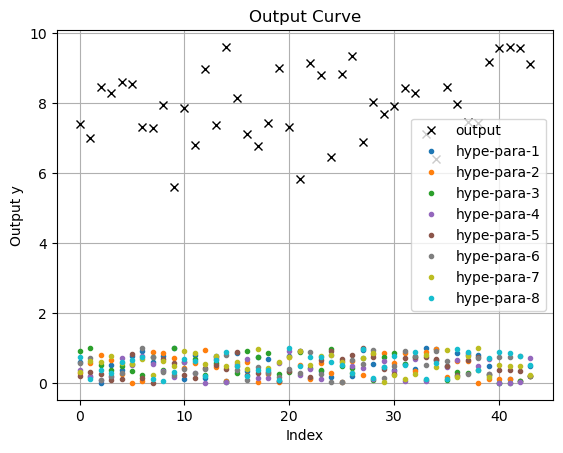

In [139]:
plot_output_points(df_sorted)

Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

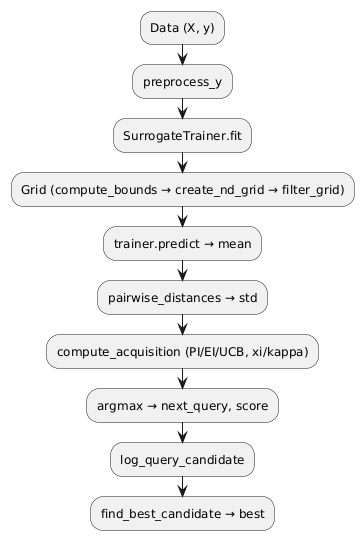

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [142]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [143]:
X = inputs
y = outputs

In [ ]:
query_results = []


In [145]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[50],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        #X_grid_full = create_nd_grid(bounds, grid_size)
        X_grid_full = create_nd_grid(bounds, grid_size, downsample=True, stride=(len(bounds)))
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Train Loss: 0.957271, Val Loss: 1.724089
Epoch 50/500, Train Loss: 0.045374, Val Loss: 0.039654
Epoch 100/500, Train Loss: 0.004185, Val Loss: 0.035817
Early stopping at epoch 113, best val_loss=0.025898


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/utils/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


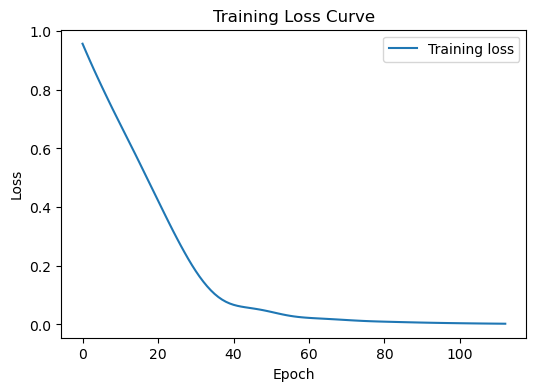

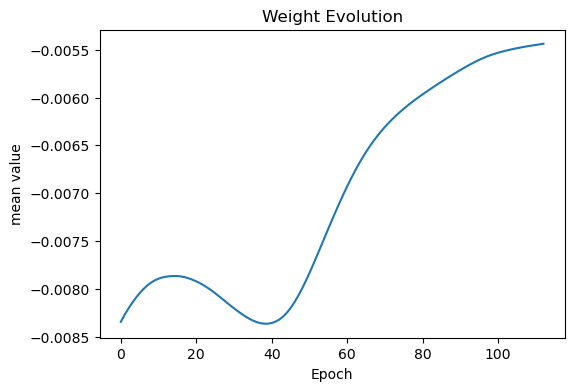

Computing bounds with margin 0.1.
Bounds per feature: [(-0.1, 1.08594538963311), (-0.09658050051593539, 1.073979787491971), (-0.1, 1.098885496855836), (-0.1, 1.002985774748292), (-0.09035112200825415, 1.086901999632929), (-0.07788659312394111, 1.0902438143772586), (-0.06409112383045615, 1.092914494924961), (-0.05804393054297677, 1.0887551042522277)]
Using 8 dimensions.
Points before downsampling: 39062500000000
Points after downsampling: 5764801
Final grid shape: (5764801, 8)
Filtering grid using mode: knn
Grid shape before filtering: (5764801, 8)


In [ ]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='knn')

In [ ]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [ ]:
print("Best Hyperparameter Configuration:")
print(best)

In [ ]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

In [ ]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')